In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define data transformations for data augmentation and normalization
data_transforms = {
    'Training': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Testing': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Define the data directory
data_dir = 'dataset2'

# Create data loaders
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Training', 'Testing']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4) for x in ['Training', 'Testing']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['Training', 'Testing']}
print(dataset_sizes)

class_names = image_datasets['Training'].classes
num_classes = len(class_names)

# Load the pre-trained ResNet-18 model
# Update this line to use the 'weights' parameter
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modify the final layer to match the number of classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# Freeze all layers except the final classification layer
for name, param in model.named_parameters():
    if "fc" in name:  # Unfreeze the final classification layer
        param.requires_grad = True
    else:
        param.requires_grad = False

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)  # Use all parameters

# Move the model to the GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

num_epochs = 2 # Reduce the number of epochs for testing
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)
    for phase in ['Training', 'Testing']:
        if phase == 'Training':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for i, (inputs, labels) in enumerate(dataloaders[phase]):
            if i % 10 == 0:
                print(f'Batch {i}/{len(dataloaders[phase])}')
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Training'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'Training':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

print("Training complete!")

model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'brain_classification_model.pth')
torch.save(model.state_dict(), model_path)
print(f'Model saved to {model_path}')
print(f'Current working directory: {os.getcwd()}')


{'Training': 5712, 'Testing': 1311}
Epoch 1/2
----------
Batch 0/1428
Batch 10/1428
Batch 20/1428
Batch 30/1428
Batch 40/1428
Batch 50/1428
Batch 60/1428
Batch 70/1428
Batch 80/1428
Batch 90/1428
Batch 100/1428
Batch 110/1428
Batch 120/1428
Batch 130/1428
Batch 140/1428
Batch 150/1428
Batch 160/1428
Batch 170/1428
Batch 180/1428
Batch 190/1428
Batch 200/1428
Batch 210/1428
Batch 220/1428
Batch 230/1428
Batch 240/1428
Batch 250/1428
Batch 260/1428
Batch 270/1428
Batch 280/1428
Batch 290/1428
Batch 300/1428
Batch 310/1428
Batch 320/1428
Batch 330/1428
Batch 340/1428
Batch 350/1428
Batch 360/1428
Batch 370/1428
Batch 380/1428
Batch 390/1428
Batch 400/1428
Batch 410/1428
Batch 420/1428
Batch 430/1428
Batch 440/1428
Batch 450/1428
Batch 460/1428
Batch 470/1428
Batch 480/1428
Batch 490/1428
Batch 500/1428
Batch 510/1428
Batch 520/1428
Batch 530/1428
Batch 540/1428
Batch 550/1428
Batch 560/1428
Batch 570/1428
Batch 580/1428
Batch 590/1428
Batch 600/1428
Batch 610/1428
Batch 620/1428
Batch 630

In [1]:
import torch
from torch import nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the saved model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1000)  # Adjust to match the original model's output units
model.load_state_dict(torch.load('brain_classification_model.pth'))
model.eval()

# Create a new model with the correct final layer
new_model = models.resnet18(pretrained=True)
new_model.fc = nn.Linear(new_model.fc.in_features, 4)  # Adjust to match the desired output units

# Copy the weights and biases from the loaded model to the new model
new_model.fc.weight.data = model.fc.weight.data[:4]  # Copy only the first 4 output units
new_model.fc.bias.data = model.fc.bias.data[:4]

# Prepare your new image for classification
image_path = 'Testing.jpg'  # Replace with the path to your image
image = Image.open(image_path)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)  # Add a batch dimension

# Perform inference with the new model
new_model.eval()
with torch.no_grad():
    output = new_model(input_batch)

# Get the predicted class
_, predicted_class = output.max(1)

# Map the predicted class to the class name
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']  # Make sure these class names match your training data
predicted_class_name = class_names[predicted_class.item()]

# Display the image with the predicted class name
image = np.array(image)
plt.imshow(image)
plt.axis('off')
plt.text(10, 10, f'Predicted: {predicted_class_name}', fontsize=12, color='white', backgroundcolor='red')
plt.show()


C:\Users\pisip\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\pisip\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FileNotFoundError: [Errno 2] No such file or directory: 'brain_classification_model.pth'

In [1]:
import torch
from torch import nn
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# Print current working directory
print("Current working directory:", os.getcwd())

# Ensure the correct path to the model file
model_path = 'C:/Users/pisip/Desktop/notes 2-2/brain_9.jpg'  # Update this to the correct path if necessary

# Check if the file exists
if not os.path.isfile(model_path):
    raise FileNotFoundError(f"No such file: '{model_path}'")

# Load the saved model
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 1000)  # Adjust to match the original model's output units
model.load_state_dict(torch.load(model_path))
model.eval()

# Create a new model with the correct final layer
new_model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
new_model.fc = nn.Linear(new_model.fc.in_features, 4)  # Adjust to match the desired output units

# Copy the weights and biases from the loaded model to the new model
new_model.fc.weight.data = model.fc.weight.data[:4]  # Copy only the first 4 output units
new_model.fc.bias.data = model.fc.bias.data[:4]

# Prepare your new image for classification
image_path = 'Testing.jpg'  # Replace with the path to your image
image = Image.open(image_path)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)  # Add a batch dimension

# Perform inference with the new model
new_model.eval()
with torch.no_grad():
    output = new_model(input_batch)

# Get the predicted class
_, predicted_class = output.max(1)

# Map the predicted class to the class name
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']  # Make sure these class names match your training data
predicted_class_name = class_names[predicted_class.item()]

# Display the image with the predicted class name
image = np.array(image)
plt.imshow(image)
plt.axis('off')
plt.text(10, 10, f'Predicted: {predicted_class_name}', fontsize=12, color='white', backgroundcolor='red')
plt.show()


Current working directory: C:\Users\pisip\Desktop\dataset


UnpicklingError: invalid load key, '\xff'.

Current working directory: C:\Users\pisip\Desktop\dataset


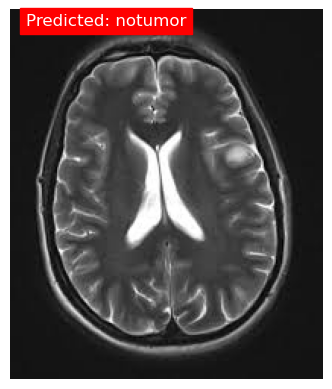

In [3]:
import torch
from torch import nn
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# Print current working directory
print("Current working directory:", os.getcwd())

# Ensure the correct path to the model file
model_path = 'C:/Users/pisip/Desktop/dataset/models/brain_classification_model.pth'  # Update this to the correct path if necessary

# Check if the file exists
if not os.path.isfile(model_path):
    raise FileNotFoundError(f"No such file: '{model_path}'")

# Load the saved model with 4 output units
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 4)  # Adjust to match the saved model's output units
model.load_state_dict(torch.load(model_path))
model.eval()

# Prepare your new image for classification
image_path = 'C:/Users/pisip/Desktop/notes 2-2/brain_mri6.jpg' # Replace with the path to your image
image = Image.open(image_path)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)  # Add a batch dimension

# Perform inference with the model
with torch.no_grad():
    output = model(input_batch)

# Get the predicted class
_, predicted_class = output.max(1)

# Map the predicted class to the class name
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']  # Make sure these class names match your training data
predicted_class_name = class_names[predicted_class.item()]

# Display the image with the predicted class name
image = np.array(image)
plt.imshow(image)
plt.axis('off')
plt.text(10, 10, f'Predicted: {predicted_class_name}', fontsize=12, color='white', backgroundcolor='red')
plt.show()
